<a href="https://colab.research.google.com/github/pratikshabhadani/Aditi-/blob/main/PageRank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

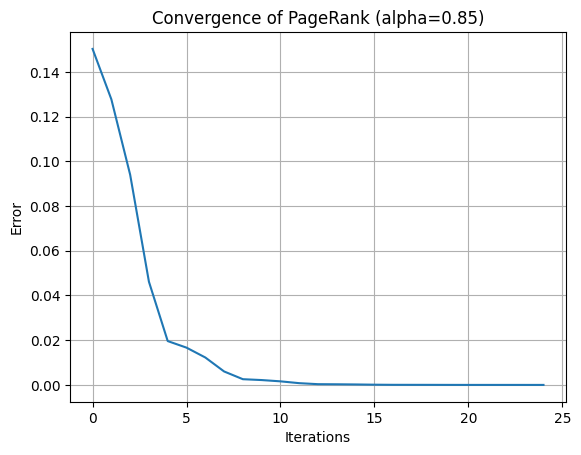

Alpha vs Iterations:
0.6 : 16
0.85 : 25
0.95 : 33


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example graph (4 nodes)
P = np.array([
    [0,   0,   1,   0],
    [1/2, 0,   0,   0],
    [1/2, 1,   0,   0],
    [0,   0,   0,   1]
], dtype=float)

n = P.shape[0]
v = np.ones(n) / n  # teleport vector

def pagerank(alpha, tol=1e-6, max_iter=100):
    x = np.ones(n) / n
    errors = []

    for i in range(max_iter):
        x_new = alpha * P @ x + (1 - alpha) * v
        err = np.linalg.norm(x_new - x)
        errors.append(err)
        if err < tol:
            break
        x = x_new

    return x, errors, i+1

# ---------- Experiment 1: Convergence ----------
x, errors, iters = pagerank(0.85)

plt.plot(errors)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.title("Convergence of PageRank (alpha=0.85)")
plt.grid()
plt.show()

# ---------- Experiment 2: Effect of alpha ----------
alphas = [0.6, 0.85, 0.95]
iterations = []

for a in alphas:
    _, _, it = pagerank(a)
    iterations.append(it)

print("Alpha vs Iterations:")
for a, it in zip(alphas, iterations):
    print(a, ":", it)

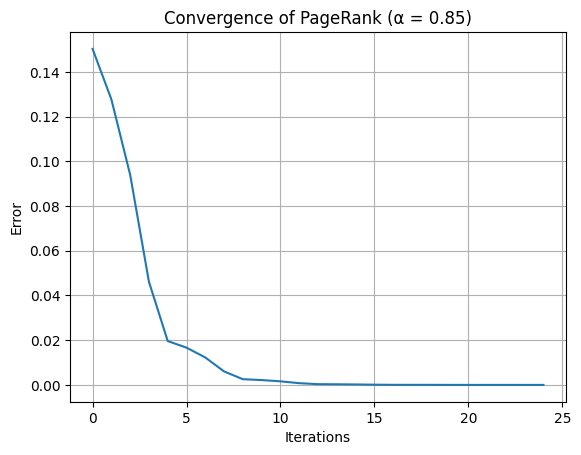


Final PageRank (α = 0.85):
[0.29084208 0.16110788 0.29805003 0.25      ]
Iterations: 25

Effect of α on convergence:

α = 0.6
Iterations: 16
PageRank: [0.27528087 0.18258434 0.29213479 0.25      ]

α = 0.85
Iterations: 25
PageRank: [0.29084208 0.16110788 0.29805003 0.25      ]

α = 0.95
Iterations: 33
PageRank: [0.2969806  0.15356579 0.29945361 0.25      ]

Ranking order for different α:
α = 0.6 → Ranking: [2 0 3 1]
α = 0.85 → Ranking: [2 0 3 1]
α = 0.95 → Ranking: [2 0 3 1]

In-degree of nodes:
[1 1 2 1]

PageRank vs In-degree comparison:
Node | In-degree | PageRank (α=0.85)
0    | 1         | 0.2908
1    | 1         | 0.1611
2    | 2         | 0.2981
3    | 1         | 0.2500


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Graph (same as your matrix)
# -----------------------------
P = np.array([
    [0,   0,   1,   0],
    [1/2, 0,   0,   0],
    [1/2, 1,   0,   0],
    [0,   0,   0,   1]
], dtype=float)

n = P.shape[0]
v = np.ones(n) / n  # teleport vector

# -----------------------------
# PageRank function
# -----------------------------
def pagerank(alpha, tol=1e-6, max_iter=100):
    x = np.ones(n) / n
    errors = []

    for i in range(max_iter):
        x_new = alpha * (P @ x) + (1 - alpha) * v
        err = np.linalg.norm(x_new - x)
        errors.append(err)
        if err < tol:
            return x_new, errors, i+1
        x = x_new

    return x, errors, max_iter

# -----------------------------
# EXPERIMENT 1: Convergence
# -----------------------------
x, errors, iters = pagerank(0.85)

plt.figure()
plt.plot(errors)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.title("Convergence of PageRank (α = 0.85)")
plt.grid()
plt.show()

print("\nFinal PageRank (α = 0.85):")
print(x)
print("Iterations:", iters)

# -----------------------------
# EXPERIMENT 2: Effect of α
# -----------------------------
alphas = [0.6, 0.85, 0.95]

print("\nEffect of α on convergence:")
results = []

for a in alphas:
    x_val, _, it = pagerank(a)
    results.append((a, it, x_val))
    print(f"\nα = {a}")
    print("Iterations:", it)
    print("PageRank:", x_val)

# -----------------------------
# EXPERIMENT 3: Ranking Comparison
# -----------------------------
print("\nRanking order for different α:")

for a, _, x_val in results:
    order = np.argsort(-x_val)  # descending
    print(f"α = {a} → Ranking:", order)

# -----------------------------
# EXPERIMENT 4: In-degree vs PageRank
# -----------------------------
in_degree = np.sum(P > 0, axis=1)

print("\nIn-degree of nodes:")
print(in_degree)

print("\nPageRank vs In-degree comparison:")
print("Node | In-degree | PageRank (α=0.85)")
for i in range(n):
    print(f"{i}    | {in_degree[i]}         | {x[i]:.4f}")

Running experiments...

alpha = 0.6
  Iterations = 29
  |lambda_2| = 0.4290

alpha = 0.75
  Iterations = 48
  |lambda_2| = 0.5362

alpha = 0.85
  Iterations = 87
  |lambda_2| = 0.6077

alpha = 0.95
  Iterations = 100
  |lambda_2| = 0.6792



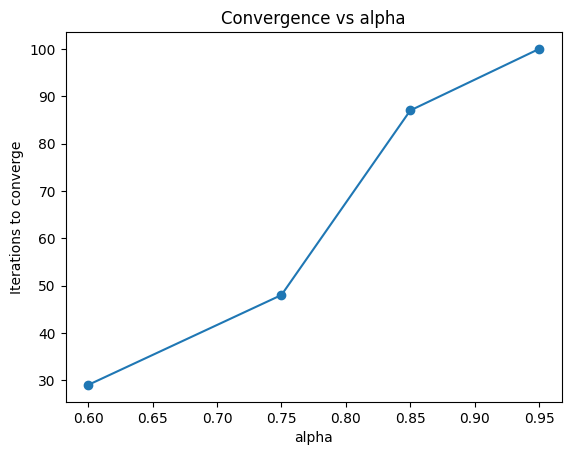

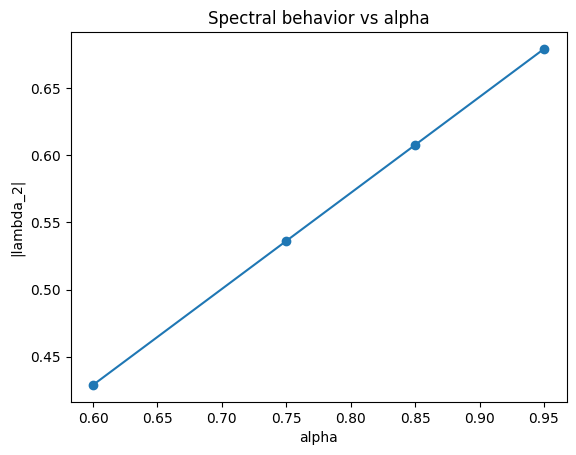

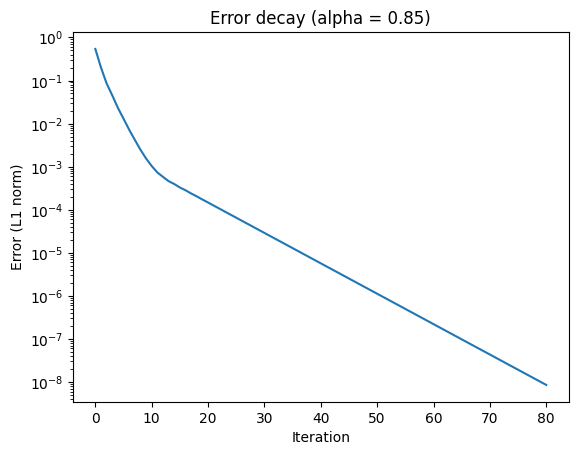

Top 10 nodes (default PageRank):
[ 10   0  20   1  25  29  33  21 454 445]

Top 10 nodes (personalized PageRank, seed=0):
[  0 384 482 457 187 137 470 213 180   2]


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

# -----------------------------
# Step 1: Create Graph
# -----------------------------
n = 500
G = nx.barabasi_albert_graph(n, 3, seed=42)
G = G.to_directed()

# -----------------------------
# Step 2: Build Transition Matrix
# -----------------------------
A = nx.to_scipy_sparse_array(G, dtype=float)
n = A.shape[0]

out_degree = np.array(A.sum(axis=1)).flatten()

# Handle dangling nodes
dangling = (out_degree == 0)
out_degree[dangling] = 1

P = A.multiply(1 / out_degree[:, None])

# -----------------------------
# Step 3: Power Iteration (FIXED)
# -----------------------------
def pagerank_power(P, alpha=0.85, tol=1e-8, max_iter=100):
    n = P.shape[0]

    # ✅ Random initialization (fixes 0-iteration issue)
    x = np.random.rand(n)
    x = x / x.sum()

    v = np.ones(n) / n
    errors = []

    for i in range(max_iter):
        x_new = alpha * (P @ x) + (1 - alpha) * v

        err = np.linalg.norm(x_new - x, 1)
        errors.append(err)

        if err < tol:
            return x_new, i + 1, errors

        x = x_new

    return x, max_iter, errors

# -----------------------------
# Step 4: Compute lambda_2
# -----------------------------
def compute_lambda2(P, alpha):
    n = P.shape[0]
    v = np.ones(n) / n

    G_matrix = alpha * P.toarray() + (1 - alpha) * np.outer(np.ones(n), v)

    vals, _ = eigs(G_matrix.T, k=2, which='LM')
    vals = np.abs(vals)

    vals_sorted = np.sort(vals)
    return vals_sorted[-2]

# -----------------------------
# Step 5: Alpha Experiments
# -----------------------------
alphas = [0.6, 0.75, 0.85, 0.95]

iterations = []
lambda2_vals = []

print("Running experiments...\n")

for alpha in alphas:
    pr, iters, errors = pagerank_power(P, alpha=alpha)
    lam2 = compute_lambda2(P, alpha)

    iterations.append(iters)
    lambda2_vals.append(lam2)

    print(f"alpha = {alpha}")
    print(f"  Iterations = {iters}")
    print(f"  |lambda_2| = {lam2:.4f}")
    print()

# -----------------------------
# Step 6: Plot Results
# -----------------------------
plt.figure()
plt.plot(alphas, iterations, marker='o')
plt.xlabel("alpha")
plt.ylabel("Iterations to converge")
plt.title("Convergence vs alpha")
plt.show()

plt.figure()
plt.plot(alphas, lambda2_vals, marker='o')
plt.xlabel("alpha")
plt.ylabel("|lambda_2|")
plt.title("Spectral behavior vs alpha")
plt.show()

# -----------------------------
# Step 7: Plot Error Decay (for one alpha)
# -----------------------------
_, _, errors = pagerank_power(P, alpha=0.85)

plt.figure()
plt.plot(errors)
plt.xlabel("Iteration")
plt.ylabel("Error (L1 norm)")
plt.title("Error decay (alpha = 0.85)")
plt.yscale("log")
plt.show()

# -----------------------------
# Step 8: Personalized PageRank
# -----------------------------
def personalized_pagerank(P, alpha, seed_node, max_iter=100):
    n = P.shape[0]

    v = np.zeros(n)
    v[seed_node] = 1

    x = np.random.rand(n)
    x = x / x.sum()

    for _ in range(max_iter):
        x = alpha * (P @ x) + (1 - alpha) * v

    return x

# -----------------------------
# Step 9: Compare Rankings
# -----------------------------
pr_default, _, _ = pagerank_power(P)
pr_personal = personalized_pagerank(P, 0.85, seed_node=0)

print("Top 10 nodes (default PageRank):")
print(np.argsort(-pr_default)[:10])

print("\nTop 10 nodes (personalized PageRank, seed=0):")
print(np.argsort(-pr_personal)[:10])

=== Spectral Analysis ===

alpha = 0.6
  Iterations = 30
  |lambda_2| = 0.4290

alpha = 0.75
  Iterations = 52
  |lambda_2| = 0.5362

alpha = 0.85
  Iterations = 80
  |lambda_2| = 0.6077

alpha = 0.95
  Iterations = 200
  |lambda_2| = 0.6792



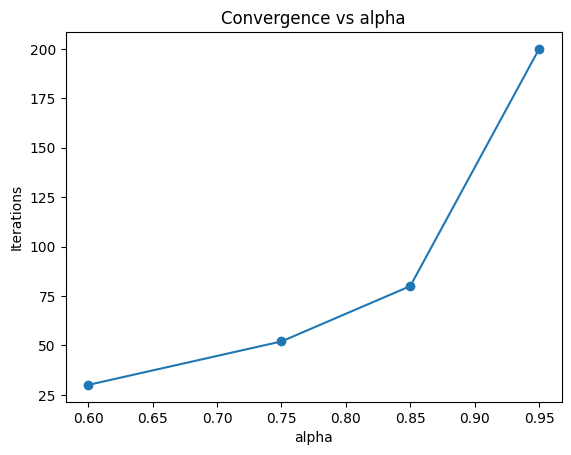

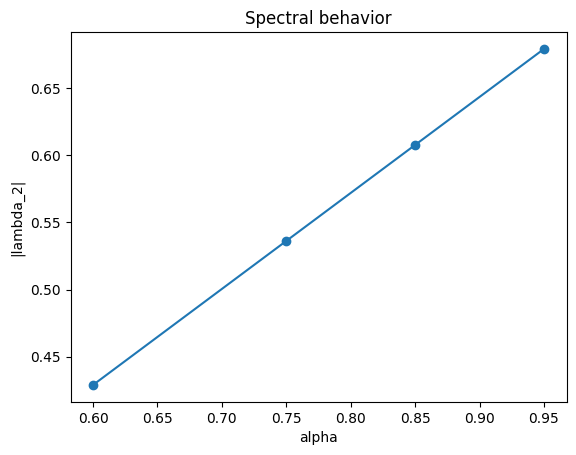

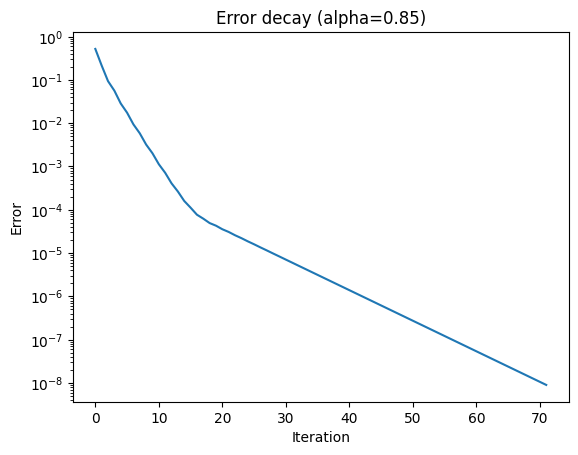


=== Real Dataset Analysis ===

PageRank iterations (real graph): 84

Top 10 (PageRank): [26 29 23 25 24 20 14 15 22 18]
Top 10 (In-degree): [33  0 32  2  1  3 31 13 23  8]

Overlap in top 10: 1


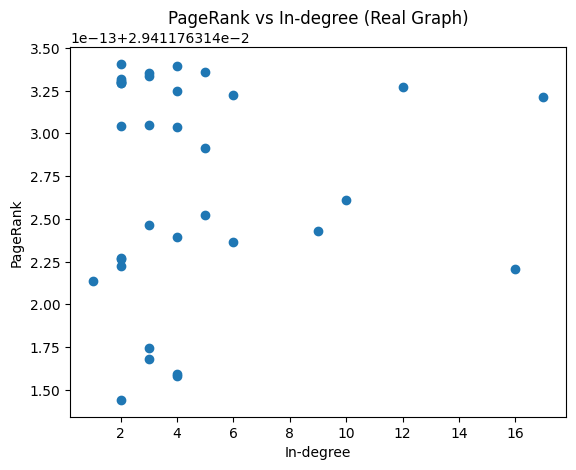


Correlation: 0.04376888410092493


In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

# =====================================================
# PART 1: BUILD GRAPH (synthetic for spectral analysis)
# =====================================================
n = 500
G = nx.barabasi_albert_graph(n, 3, seed=42)
G = G.to_directed()

A = nx.to_scipy_sparse_array(G, dtype=float)
n = A.shape[0]

out_degree = np.array(A.sum(axis=1)).flatten()
out_degree[out_degree == 0] = 1  # handle dangling nodes

P = A.multiply(1 / out_degree[:, None])

# =====================================================
# PageRank function
# =====================================================
def pagerank_power(P, alpha=0.85, tol=1e-8, max_iter=200):
    n = P.shape[0]

    x = np.random.rand(n)
    x = x / x.sum()

    v = np.ones(n) / n
    errors = []

    for i in range(max_iter):
        x_new = alpha * (P @ x) + (1 - alpha) * v

        err = np.linalg.norm(x_new - x, 1)
        errors.append(err)

        if err < tol:
            return x_new, i + 1, errors

        x = x_new

    return x, max_iter, errors

# =====================================================
# Compute lambda_2
# =====================================================
def compute_lambda2(P, alpha):
    n = P.shape[0]
    v = np.ones(n) / n

    G_matrix = alpha * P.toarray() + (1 - alpha) * np.outer(np.ones(n), v)

    vals, _ = eigs(G_matrix.T, k=2, which='LM')
    vals = np.abs(vals)

    vals_sorted = np.sort(vals)
    return vals_sorted[-2]

# =====================================================
# PART 2: ALPHA EXPERIMENTS
# =====================================================
alphas = [0.6, 0.75, 0.85, 0.95]

iterations = []
lambda2_vals = []

print("=== Spectral Analysis ===\n")

for alpha in alphas:
    pr, iters, errors = pagerank_power(P, alpha=alpha)
    lam2 = compute_lambda2(P, alpha)

    iterations.append(iters)
    lambda2_vals.append(lam2)

    print(f"alpha = {alpha}")
    print(f"  Iterations = {iters}")
    print(f"  |lambda_2| = {lam2:.4f}\n")

# =====================================================
# PLOTS (Spectral Analysis)
# =====================================================
plt.figure()
plt.plot(alphas, iterations, marker='o')
plt.xlabel("alpha")
plt.ylabel("Iterations")
plt.title("Convergence vs alpha")
plt.show()

plt.figure()
plt.plot(alphas, lambda2_vals, marker='o')
plt.xlabel("alpha")
plt.ylabel("|lambda_2|")
plt.title("Spectral behavior")
plt.show()

# Error decay
_, _, errors = pagerank_power(P, alpha=0.85)

plt.figure()
plt.plot(errors)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error decay (alpha=0.85)")
plt.show()

# =====================================================
# PART 3: REAL DATASET COMPARISON
# =====================================================
print("\n=== Real Dataset Analysis ===\n")

G_real = nx.karate_club_graph()
G_real = G_real.to_directed()

A_real = nx.to_scipy_sparse_array(G_real, dtype=float)
n_real = A_real.shape[0]

out_degree_real = np.array(A_real.sum(axis=1)).flatten()
out_degree_real[out_degree_real == 0] = 1

P_real = A_real.multiply(1 / out_degree_real[:, None])

# PageRank on real graph
pr_real, iters_real, _ = pagerank_power(P_real)

print("PageRank iterations (real graph):", iters_real)

# In-degree
in_degrees = dict(G_real.in_degree())
in_deg_array = np.array([in_degrees[i] for i in range(len(in_degrees))])

# Top nodes
top_pr = np.argsort(-pr_real)[:10]
top_indeg = np.argsort(-in_deg_array)[:10]

print("\nTop 10 (PageRank):", top_pr)
print("Top 10 (In-degree):", top_indeg)

# Overlap
overlap = len(set(top_pr) & set(top_indeg))
print("\nOverlap in top 10:", overlap)

# Scatter plot
plt.figure()
plt.scatter(in_deg_array, pr_real)
plt.xlabel("In-degree")
plt.ylabel("PageRank")
plt.title("PageRank vs In-degree (Real Graph)")
plt.show()

# Correlation
corr = np.corrcoef(in_deg_array, pr_real)[0,1]
print("\nCorrelation:", corr)